# CNN learning map

**Learning objective:** Understand why convolution is useful for spatial data and how the track progresses from pixels to production evaluation.

This notebook is part of the TensorFlow/Keras learning track. It is designed to be read top-to-bottom: intuition → shapes → mathematics → TensorFlow implementation → observed result → interpretation.

> GitHub renders the committed executed output as a static learning artifact. Clone the repository and rerun it in Jupyter/VS Code for live experimentation.


In [1]:
import os, warnings, random
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "bundled with TensorFlow")
print("Execution device(s):", [d.device_type for d in tf.config.list_logical_devices()])


2026-09-21 07:15:17.671736: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789974917.686918    3694 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789974917.691291    3694 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.1
Keras: 3.15.1
Execution device(s): ['CPU']


2026-09-21 07:15:19.394703: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


CNNs preserve spatial locality. Instead of connecting every pixel to every hidden unit, a convolution learns small reusable filters that scan the image. Deeper layers combine local patterns into increasingly abstract representations.


In [2]:
stages=pd.DataFrame({"stage":["pixels","convolution","activation","pooling","deeper features","classifier"],"question":["what values exist?","what local pattern is present?","which responses matter?","what can be compressed?","what larger pattern emerges?","which class fits?"]})
display(stages)


,stage,question
0,pixels,what values exist?
1,convolution,what local pattern is present?
2,activation,which responses matter?
3,pooling,what can be compressed?
4,deeper features,what larger pattern emerges?
5,classifier,which class fits?


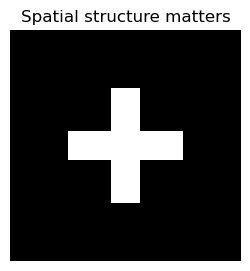

In [3]:
img=np.zeros((16,16)); img[4:12,7:9]=1; img[7:9,4:12]=1
plt.figure(figsize=(3,3)); plt.imshow(img,cmap="gray"); plt.title("Spatial structure matters"); plt.axis("off"); plt.show()
